In [16]:
# Cell 1: 環境
from google.colab import drive
drive.mount('/content/drive')
!nvidia-smi
!pip install clean-fid --quiet

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mon Sep 14 03:07:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P0             54W /  400W |    1612MiB /  40960MiB |      0%      Default |
|          

In [17]:
# Cell 2: 拉最新程式碼（單一事實來源 = GitHub）
!git clone https://github.com/yjjj3/ddpm-from-scratch.git
%cd ddpm-from-scratch

Cloning into 'ddpm-from-scratch'...
remote: Enumerating objects: 99, done.
remote: Counting objects: 100% (99/99), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 99 (delta 34), reused 21 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (99/99), 1.77 MiB | 22.08 MiB/s, done.
Resolving deltas: 100% (34/34), done.
/content/ddpm-from-scratch/ddpm-from-scratch


In [18]:
# Cell 3: import
from ddpm_mnist import CFG, UNet, Diffusion, train
from ddim import ddim_sample
from fid_eval import prepare_real_images, run_fid_experiment, run_seed_check
from plot_utils import plot_fid_curve

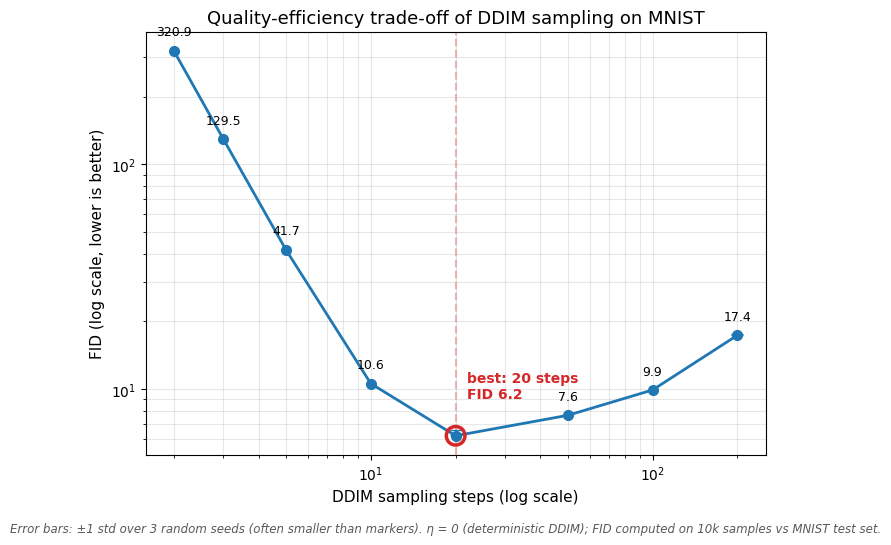

saved to /content/drive/MyDrive/ddpm_mnist/fid_curve_polished.png


In [19]:
plot_fid_curve()

/content/ddpm-from-scratch
Already up to date.


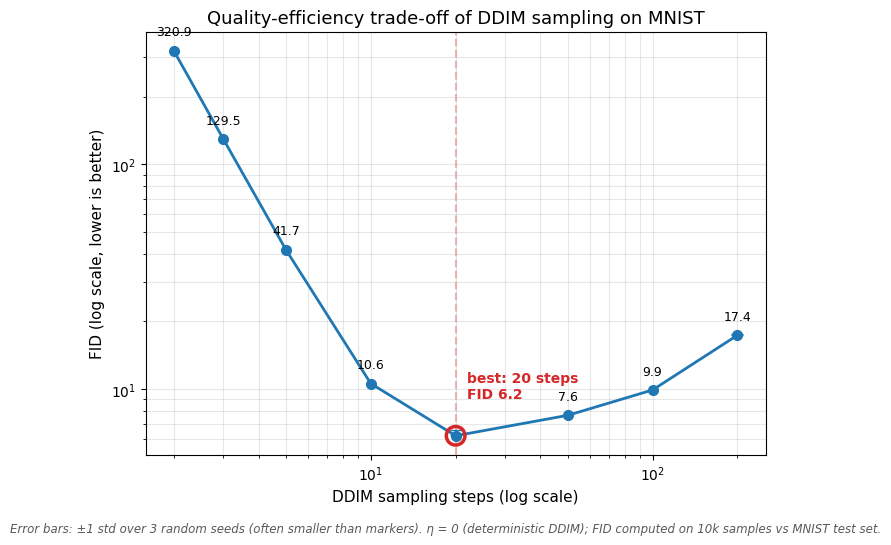

saved to /content/drive/MyDrive/ddpm_mnist/fid_curve_polished.png


In [20]:
%cd /content/ddpm-from-scratch
!git pull

import importlib
import plot_utils
importlib.reload(plot_utils)
from plot_utils import plot_fid_curve

plot_fid_curve()

In [21]:
from google.colab import drive
drive.mount('/content/drive')

import torch
from pathlib import Path

folder = Path('/content/drive/MyDrive/ddpm_mnist')
checkpoint_path = folder / 'latest.pt'

print('GPU 可用：', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU：', torch.cuda.get_device_name(0))

print('權重存在：', checkpoint_path.exists())
print('FID 結果存在：', (folder / 'fid_results.json').exists())

if not torch.cuda.is_available():
    raise RuntimeError('請先切換至 GPU 執行階段')

if not checkpoint_path.exists():
    raise FileNotFoundError(
        f'請將 latest.pt 放到 Google Drive 的 MyDrive/ddpm_mnist 資料夾：'
        f'{checkpoint_path}'
    )

checkpoint = torch.load(
    checkpoint_path,
    map_location='cpu',
    weights_only=True,
)

print('Checkpoint 欄位：', list(checkpoint.keys()))
print('已訓練步數：', checkpoint.get('step'))
print('包含 EMA 權重：', 'ema' in checkpoint)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU 可用： True
GPU： NVIDIA A100-SXM4-40GB
權重存在： True
FID 結果存在： True
Checkpoint 欄位： ['model', 'ema', 'opt', 'step']
已訓練步數： 30000
包含 EMA 權重： True


In [29]:
# 裁切消融：直接在目前 Colab 執行
%cd /content/ddpm-from-scratch
%pip -q install clean-fid

import gc
import json
import time
import hashlib
import tempfile
import shutil
from pathlib import Path

import torch
from torchvision.utils import save_image
from cleanfid import fid
from ddpm_mnist import CFG, UNet, Diffusion
from fid_eval import prepare_real_images, REAL_DIR

DEVICE = "cuda"
STEPS = [20, 50, 200]
MODES = ["no_clip", "clip_original", "clip_recompute"]
NUM_IMAGES = 10_000
BATCH_SIZE = 100
SEED = 123

checkpoint_path = Path(
    "/content/drive/MyDrive/ddpm_independent/"
    "train_seed_2026/latest.pt"
)
checkpoint_hash = hashlib.sha256(checkpoint_path.read_bytes()).hexdigest()

CFG.device = DEVICE
diffusion = Diffusion(CFG)
model = UNet(CFG).to(DEVICE)

checkpoint = torch.load(
    checkpoint_path, map_location="cpu", weights_only=True
)
model.load_state_dict(checkpoint["ema"], strict=True)
model.eval()
del checkpoint
gc.collect()

# 獨立實驗資料夾；同設定重新執行時可以跳過已完成組別
experiment = {
    "version": 1,
    "checkpoint_sha256": checkpoint_hash,
    "steps": STEPS,
    "modes": MODES,
    "num_images": NUM_IMAGES,
    "batch_size": BATCH_SIZE,
    "seed": SEED,
    "T": CFG.T,
    "beta_start": CFG.beta_start,
    "beta_end": CFG.beta_end,
    "image_size": CFG.image_size,
    "channels": CFG.channels,
    "torch": torch.__version__,
    "gpu": torch.cuda.get_device_name(0),
}
experiment_id = hashlib.sha256(
    json.dumps(experiment, sort_keys=True).encode()
).hexdigest()[:12]

output_dir = checkpoint_path.parent / f"clipping_ablation_{experiment_id}"
output_dir.mkdir(parents=True, exist_ok=True)
results_path = output_dir / "results.json"

if results_path.exists():
    report = json.loads(results_path.read_text())
else:
    report = {"config": experiment, "results": {}}

def save_report():
    temporary = results_path.with_suffix(".tmp")
    temporary.write_text(
        json.dumps(report, indent=2, ensure_ascii=False)
    )
    temporary.replace(results_path)

save_report()


@torch.inference_mode()
def sample(initial_noise, num_steps, mode):
    """eta=0；除裁切方式外，其餘更新與原 sampler 相同。"""
    x = initial_noise.clone()
    times = torch.linspace(
        diffusion.T - 1, 0, num_steps, dtype=torch.long
    ).tolist()

    for i, t in enumerate(times):
        previous = times[i + 1] if i + 1 < len(times) else -1
        ab = diffusion.alpha_bars[t]
        ab_previous = (
            diffusion.alpha_bars[previous]
            if previous >= 0
            else x.new_tensor(1.0)
        )

        t_batch = torch.full(
            (x.shape[0],), t, device=DEVICE, dtype=torch.long
        )
        eps = model(x, t_batch)
        x0 = (x - (1 - ab).sqrt() * eps) / ab.sqrt()

        if mode != "no_clip":
            x0 = x0.clamp(-1, 1)

        if mode == "clip_recompute":
            eps = (x - ab.sqrt() * x0) / (1 - ab).sqrt()

        x = ab_previous.sqrt() * x0 + (1 - ab_previous).sqrt() * eps

    return x


prepare_real_images()

# 固定圖片對照用的起始噪聲
preview_generator = torch.Generator(device=DEVICE).manual_seed(2026)
preview_noise = torch.randn(
    16, CFG.channels, CFG.image_size, CFG.image_size,
    device=DEVICE, generator=preview_generator
)

for mode in MODES:
    for steps in STEPS:
        key = f"{mode}_{steps}"

        if key in report["results"]:
            print("已完成，跳過：", key)
            continue

        print(f"\n開始：{key}", flush=True)

        # 暖機，不納入時間
        sample(preview_noise, steps, mode)
        torch.cuda.synchronize()

        # 每組重設同一 seed，確保使用相同起始噪聲
        generator = torch.Generator(device=DEVICE).manual_seed(SEED)
        fake_dir = Path(tempfile.mkdtemp(prefix="ddim_ablation_"))
        generation_seconds = 0.0
        outside_pixels = 0
        total_pixels = 0

        try:
            for start in range(0, NUM_IMAGES, BATCH_SIZE):
                n = min(BATCH_SIZE, NUM_IMAGES - start)
                noise = torch.randn(
                    n, CFG.channels, CFG.image_size, CFG.image_size,
                    device=DEVICE, generator=generator
                )

                torch.cuda.synchronize()
                begin = time.perf_counter()
                images = sample(noise, steps, mode)
                torch.cuda.synchronize()
                generation_seconds += time.perf_counter() - begin

                if not torch.isfinite(images).all().item():
                    raise RuntimeError(f"{key} 產生 NaN 或 Inf")

                outside_pixels += (
                    (images < -1) | (images > 1)
                ).sum().item()
                total_pixels += images.numel()

                # 所有方法都以同樣方式轉為合法像素供 FID 評估。
                # no_clip 指的是不做「中間步驟」裁切。
                images = ((images.clamp(-1, 1) + 1) / 2).cpu()
                for j, img in enumerate(images):
                    save_image(img, fake_dir / f"{start+j:05d}.png")

                if (start + n) % 2000 == 0:
                    print(f"  已生成 {start+n}/{NUM_IMAGES}", flush=True)

            score = float(fid.compute_fid(
                str(REAL_DIR), str(fake_dir),
                mode="clean", device=torch.device(DEVICE)
            ))

            preview = sample(preview_noise, steps, mode)
            save_image(
                ((preview.clamp(-1, 1) + 1) / 2).cpu(),
                output_dir / f"{key}.png",
                nrow=4
            )

            report["results"][key] = {
                "mode": mode,
                "steps": steps,
                "fid": score,
                "generation_seconds": generation_seconds,
                "images_per_second": NUM_IMAGES / generation_seconds,
                "final_out_of_range_fraction": outside_pixels / total_pixels,
            }
            save_report()
            print(
                f"完成：FID={score:.4f}, "
                f"生成時間={generation_seconds:.1f} 秒",
                flush=True
            )
        finally:
            shutil.rmtree(fake_dir, ignore_errors=True)

print("\n全部完成！結果位置：", results_path)
for key, result in report["results"].items():
    print(f"{key:24s} FID={result['fid']:.4f}")

/content/ddpm-from-scratch
real images already prepared

開始：no_clip_20
  已生成 2000/10000
  已生成 4000/10000
  已生成 6000/10000
  已生成 8000/10000
  已生成 10000/10000
compute FID between two folders
Found 10000 images in the folder /content/fid_real


FID fid_real : 100%|██████████| 313/313 [00:14<00:00, 20.97it/s]


Found 10000 images in the folder /tmp/ddim_ablation_qv5w4cjc


FID ddim_ablation_qv5w4cjc : 100%|██████████| 313/313 [00:14<00:00, 21.51it/s]


完成：FID=5.3984, 生成時間=10.9 秒

開始：no_clip_50
  已生成 2000/10000
  已生成 4000/10000
  已生成 6000/10000
  已生成 8000/10000
  已生成 10000/10000
compute FID between two folders
Found 10000 images in the folder /content/fid_real


...

完成：FID=5.1231, 生成時間=26.8 秒

開始：clip_recompute_200
  已生成 2000/10000
  已生成 4000/10000
  已生成 6000/10000
  已生成 8000/10000
  已生成 10000/10000
compute FID between two folders
Found 10000 images in the folder /content/fid_real


FID fid_real : 100%|██████████| 313/313 [00:14<00:00, 20.88it/s]


Found 10000 images in the folder /tmp/ddim_ablation_h1gd4eey


FID ddim_ablation_h1gd4eey : 100%|██████████| 313/313 [00:14<00:00, 21.45it/s]


完成：FID=5.5479, 生成時間=106.1 秒

全部完成！結果位置： /content/drive/MyDrive/ddpm_independent/train_seed_2026/clipping_ablation_3b32050c4af4/results.json
no_clip_20               FID=5.3984
no_clip_50               FID=4.8641
no_clip_200              FID=5.3148
clip_original_20         FID=6.4178
clip_original_50         FID=7.5610
clip_original_200        FID=21.5824
clip_recompute_20        FID=5.6726
clip_recompute_50        FID=5.1231
clip_recompute_200       FID=5.5479


In [23]:
from google.colab import drive, files
drive.mount('/content/drive')
from pathlib import Path
import json
import zipfile

root = Path('/content/drive/MyDrive/ddpm_mnist')
checkpoint_hash = 'c4145894a7dfd44a695396070fccd142c53fff3c06c46e4d04a66a4177b3adc6'
names = [f'{mode}_{steps}.png'
         for mode in ['no_clip', 'clip_original', 'clip_recompute']
         for steps in [20, 50, 200]]
candidates = []
for path in sorted(root.glob('clipping_ablation_*/results.json')):
    report = json.loads(path.read_text())
    config = report.get('config', {})
    if (config.get('seed') == 0
        and config.get('checkpoint_sha256') == checkpoint_hash
        and config.get('num_images') == 10000
        and config.get('batch_size') == 100
        and len(report.get('results', {})) == 12
        and all((path.parent / name).exists() for name in names)):
        candidates.append(path.parent)

if len(candidates) != 1:
    raise RuntimeError(
        f'找到 {len(candidates)} 個符合條件的資料夾：{candidates}。'
        '請檢查圖片是否齊全；若有多個版本，先確認要使用哪一份。'
    )
folder = candidates[0]
archive = Path('/content/clipping_ablation_previews.zip')
with zipfile.ZipFile(archive, 'w', zipfile.ZIP_DEFLATED) as z:
    for name in names + ['results.json']:
        z.write(folder / name, arcname=name)
print('來源：', folder)
files.download(str(archive))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
來源： /content/drive/MyDrive/ddpm_mnist/clipping_ablation_fbc6b5c80578


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
from google.colab import drive
drive.mount("/content/drive")

import subprocess
from pathlib import Path
import torch

assert torch.cuda.is_available(), "請先切換到 GPU 執行階段"
print("GPU：", torch.cuda.get_device_name(0))

repo = Path("/content/ddpm-from-scratch")

if not repo.exists():
    subprocess.run(
        ["git", "clone",
         "https://github.com/yjjj3/ddpm-from-scratch.git", str(repo)],
        check=True
    )
else:
    subprocess.run(
        ["git", "-C", str(repo), "pull", "--ff-only"],
        check=True
    )

%cd /content/ddpm-from-scratch
%pip -q install clean-fid

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU： NVIDIA A100-SXM4-40GB
/content/ddpm-from-scratch


In [25]:
import importlib
import random
import json
import subprocess
import numpy as np
import torch
from pathlib import Path

import ddpm_mnist
importlib.reload(ddpm_mnist)

TRAIN_SEED = 2026

train_dir = Path(
    f"/content/drive/MyDrive/ddpm_independent/train_seed_{TRAIN_SEED}"
)
train_dir.mkdir(parents=True, exist_ok=True)

# 防止不小心接續已存在的模型
if (train_dir / "latest.pt").exists():
    raise RuntimeError(
        f"{train_dir}/latest.pt 已存在。"
        "先確認這輪是否已完成，不要刪除或覆寫。"
    )

random.seed(TRAIN_SEED)
np.random.seed(TRAIN_SEED)
torch.manual_seed(TRAIN_SEED)
torch.cuda.manual_seed_all(TRAIN_SEED)

class ExperimentCFG(ddpm_mnist.CFG):
    ckpt_dir = str(train_dir)
    device = "cuda"
    total_steps = 30_000

# 保存設定，方便追溯
config = {
    key: getattr(ExperimentCFG, key)
    for key in [
        "image_size", "channels", "T", "beta_start", "beta_end",
        "base_ch", "ch_mults", "batch_size", "lr", "total_steps",
        "ema_decay", "log_every", "ckpt_every", "ckpt_dir", "device"
    ]
}
config.update({
    "training_seed": TRAIN_SEED,
    "torch_version": torch.__version__,
    "gpu": torch.cuda.get_device_name(0),
    "git_commit": subprocess.check_output(
        ["git", "rev-parse", "HEAD"], text=True
    ).strip(),
})

(train_dir / "training_config.json").write_text(
    json.dumps(config, indent=2, ensure_ascii=False)
)

ddpm_mnist.train(ExperimentCFG)

RuntimeError: /content/drive/MyDrive/ddpm_independent/train_seed_2026/latest.pt 已存在。先確認這輪是否已完成，不要刪除或覆寫。

In [ ]:
import torch

new_checkpoint = train_dir / "latest.pt"
ck = torch.load(
    new_checkpoint,
    map_location="cpu",
    weights_only=True
)

print("新權重：", new_checkpoint)
print("訓練步數：", ck["step"])
print("包含 EMA：", "ema" in ck)

assert ck["step"] == 30_000
assert "ema" in ck
del ck
{
  "config": {
    "version": 1,
    "checkpoint_sha256": "c4145894a7dfd44a695396070fccd142c53fff3c06c46e4d04a66a4177b3adc6",
    "steps": [
      10,
      20,
      50,
      200
    ],
    "modes": [
      "no_clip",
      "clip_original",
      "clip_recompute"
    ],
    "num_images": 10000,
    "batch_size": 100,
    "seed": 0,
    "T": 1000,
    "beta_start": 0.0001,
    "beta_end": 0.02,
    "image_size": 32,
    "channels": 1,
    "torch": "2.11.0+cu128",
    "gpu": "NVIDIA A100-SXM4-40GB"
  },
  "results": {
    "no_clip_10": {
      "mode": "no_clip",
      "steps": 10,
      "fid": 10.393580592814743,
      "generation_seconds": 5.258338191000007,
      "images_per_second": 1901.741507823833,
      "final_out_of_range_fraction": 0.2826654296875
    },
    "no_clip_20": {
      "mode": "no_clip",
      "steps": 20,
      "fid": 5.3575191541220875,
      "generation_seconds": 10.28155005300016,
      "images_per_second": 972.6159916015773,
      "final_out_of_range_fraction": 0.30720859375
    },
    "no_clip_50": {
      "mode": "no_clip",
      "steps": 50,
      "fid": 4.8665226393850105,
      "generation_seconds": 25.256712531000744,
      "images_per_second": 395.9343476600821,
      "final_out_of_range_fraction": 0.33547041015625
    },
    "no_clip_200": {
      "mode": "no_clip",
      "steps": 200,
      "fid": 5.4835085089015365,
      "generation_seconds": 100.4812766879993,
      "images_per_second": 99.52102849021944,
      "final_out_of_range_fraction": 0.35367119140625
    },
    "clip_original_10": {
      "mode": "clip_original",
      "steps": 10,
      "fid": 10.961188913670043,
      "generation_seconds": 5.327144014000169,
      "images_per_second": 1877.1784606759616,
      "final_out_of_range_fraction": 0.0
    },
    "clip_original_20": {
      "mode": "clip_original",
      "steps": 20,
      "fid": 6.318038608448376,
      "generation_seconds": 10.079126358999247,
      "images_per_second": 992.1494823875685,
      "final_out_of_range_fraction": 0.0
    },
    "clip_original_50": {
      "mode": "clip_original",
      "steps": 50,
      "fid": 7.7438438999319885,
      "generation_seconds": 25.43931317299939,
      "images_per_second": 393.0923736814457,
      "final_out_of_range_fraction": 0.0
    },
    "clip_original_200": {
      "mode": "clip_original",
      "steps": 200,
      "fid": 17.50286697191484,
      "generation_seconds": 101.65310101700197,
      "images_per_second": 98.37378200914354,
      "final_out_of_range_fraction": 0.0
    },
    "clip_recompute_10": {
      "mode": "clip_recompute",
      "steps": 10,
      "fid": 10.761149443201077,
      "generation_seconds": 5.352045252001744,
      "images_per_second": 1868.4445906468843,
      "final_out_of_range_fraction": 0.0
    },
    "clip_recompute_20": {
      "mode": "clip_recompute",
      "steps": 20,
      "fid": 5.593947385884576,
      "generation_seconds": 10.60133273099973,
      "images_per_second": 943.2776287417759,
      "final_out_of_range_fraction": 0.0
    },
    "clip_recompute_50": {
      "mode": "clip_recompute",
      "steps": 50,
      "fid": 5.114542113487687,
      "generation_seconds": 25.877690110000003,
      "images_per_second": 386.433254185066,
      "final_out_of_range_fraction": 0.0
    },
    "clip_recompute_200": {
      "mode": "clip_recompute",
      "steps": 200,
      "fid": 5.7143756995161255,
      "generation_seconds": 102.66941578800129,
      "images_per_second": 97.39998930790327,
      "final_out_of_range_fraction": 0.0
    }
  }
}

In [26]:
from pathlib import Path
import torch

path = Path(
    "/content/drive/MyDrive/ddpm_independent/"
    "train_seed_2026/latest.pt"
)

ck = torch.load(path, map_location="cpu", weights_only=True)
print("訓練步數：", ck["step"])
print("包含 EMA：", "ema" in ck)
del ck

訓練步數： 30000
包含 EMA： True


In [27]:
from google.colab import files

files.download(str(results_path))
files.download(str(checkpoint_path.parent / "training_config.json"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
from pathlib import Path
import hashlib
import json
import torch
from google.colab import files

folder = Path(
    "/content/drive/MyDrive/ddpm_independent/train_seed_2026"
)
path = folder / "latest.pt"

ck = torch.load(path, map_location="cpu", weights_only=True)

record = {
    "checkpoint_sha256": hashlib.sha256(path.read_bytes()).hexdigest(),
    "completed_steps": int(ck["step"]),
    "has_ema": "ema" in ck,
}

expected_hash = (
    "41399fca5807a9531e89102a15dcc45341d30"
    "dfb9684d0883eade53cb41cc16c"
)

assert record["checkpoint_sha256"] == expected_hash, \
    "這份權重與已上傳實驗使用的權重不同"
assert record["completed_steps"] == 30_000, \
    "這份權重尚未完成 30,000 步"
assert record["has_ema"], "缺少 EMA 權重"

output = folder / "checkpoint_metadata.json"
output.write_text(json.dumps(record, indent=2))
print(json.dumps(record, indent=2))
files.download(str(output))

del ck

{
  "checkpoint_sha256": "41399fca5807a9531e89102a15dcc45341d30dfb9684d0883eade53cb41cc16c",
  "completed_steps": 30000,
  "has_ema": true
}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>